In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 88.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=5d4f9d3edeefe00a5358c619083c0fddf5f89b5402dff250940c109d8af9e644
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [26]:
# Deutsch's algorithm
# Given an unknown function f : {0,1} -> {0,1}, work out whether it is constant
# or balanced.

# There are four possible functions:
#
# f0 is constant 0
# f1 is constant 1
# f2 is the identity
# f3 is negation

# Deutsch's algorithm works with F, a quantum version of f, defined by
#
# F|x>|y> = |x>|f(x) XOR y>
#
# Explicitly define F0, F1, F2, F3 as circuits and convert them to gates.

# F0 |x>|y> = |x>|y> so it's the identity function.
F0_circuit = QuantumCircuit(2)
F0 = circuit_to_gate(F0_circuit,label="F0")

# F1 |x>|y> = |x>|NOT(y)> so it's implemented by applying X(y).
F1_circuit = QuantumCircuit(2)
F1_circuit.x(0)
F1 = circuit_to_gate(F1_circuit,label="F1")

# F2 |x>|y> = |x>|x XOR y>.
F2_circuit = QuantumCircuit(2)
# Qubit 1 is x, Qubit 0 is y. x XOR y is a CNOT from 1 to 0.
F2_circuit.cx(1, 0)
F2 = circuit_to_gate(F2_circuit,label="F2")

# F3 |x>|y> = |x>|NOT(x) XOR y>.
F3_circuit = QuantumCircuit(2)
# To do NOT(x) XOR y, we flip x, do CNOT, then flip x back.
F3_circuit.x(1)
F3_circuit.cx(1, 0)
F3_circuit.x(1)
F3 = circuit_to_gate(F3_circuit,label="F3")

In [34]:
# Choose which function we want to analyse

F = F3

In [21]:
# Check that F is implemented correctly
# In this cell and the next three, make sure you understand why your
# definition of F is correct (or not).
# Test on |00>
test = QuantumCircuit(2)
test.append(F,[0,1])
state = Statevector.from_int(0, 4) # 4 basis states on 2 qubits
state = state.evolve(test)
state.draw("latex")

<IPython.core.display.Latex object>

In [22]:
# Test on |01>
test = QuantumCircuit(2)
test.x(0) # Remember that numbering of qubits starts from the right
test.append(F,[0,1])
state = Statevector.from_int(0, 4) # 4 basis states on 2 qubits
state = state.evolve(test)
state.draw("latex")

<IPython.core.display.Latex object>

In [23]:
# Test on |10>
test = QuantumCircuit(2)
test.x(1) # Remember that numbering of qubits starts from the right
test.append(F,[0,1])
state = Statevector.from_int(0, 4) # 4 basis states on 2 qubits
state = state.evolve(test)
state.draw("latex")

<IPython.core.display.Latex object>

In [17]:
# Test on |11>
test = QuantumCircuit(2)
test.x(0)
test.x(1)
test.append(F,[0,1])
state = Statevector.from_int(0, 4) # 4 basis states on 2 qubits
state = state.evolve(test)
state.draw("latex")

<IPython.core.display.Latex object>

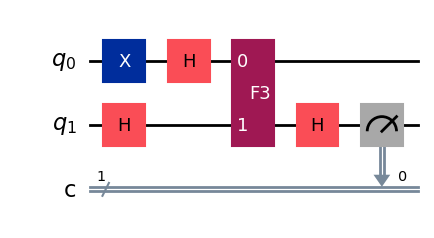

In [35]:
deutsch = QuantumCircuit(2,1)

# 1. Prepare the state |+>|->
# Target qubit (q0) to |->
deutsch.x(0)
deutsch.h(0)
# Query qubit (q1) to |+>
deutsch.h(1)

# 2. Apply the Oracle
deutsch.append(F,[0,1])

# 3. Apply H to query qubit and measure
deutsch.h(1)
deutsch.measure(1, 0)

deutsch.draw("mpl")

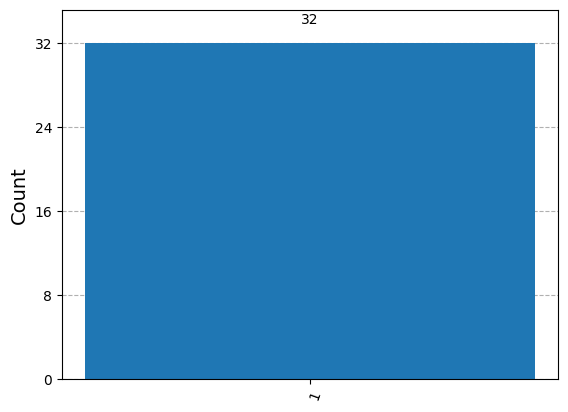

In [36]:
# Now simulate and plot the results.
# If f is constant (that is, F0 or F1) the result should always be 0.
# if f is balanced (that is, F2 or F3) the result should always be 1.

backend = BasicSimulator()
compiled = transpile(deutsch, backend)
job_sim = backend.run(compiled, shots=32)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
plot_histogram(counts)